In [14]:
import os, re
import json
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FormatStrFormatter

from datetime import datetime
import math
import pandas as pd
from itertools import chain

from utils import post_process_get_moving_test_data_and_timestamp
from utils import remove_outlier_by_quantile
from static_data_processing import get_test_files_and_survey
from plot_utils import plot_time_series_ranging, update_rate_aggregate_reporting_pairs

from pandas.core.common import SettingWithCopyWarning
import warnings
warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)

ROOT_DIR = os.path.join("C:/Users/wangz/OneDrive/University_RU/NSUWB/")
CALIBRATED_CAM_TO_V2B = -6400.8
pd.set_option('display.float_format', lambda x: '%.5f' % x)

RESAMPLE_RULE = "1S"

static_main_master = '0C1A'
static_focusing_slaves = ['1912', '8D38']
static_master_slave_mapping = { '0C1A': [static_focusing_slaves[0], static_focusing_slaves[1]],
                        '9B0F': [static_focusing_slaves[1], static_focusing_slaves[0]]}
moving_main_master = '88BA'
moving_focusing_slaves = ['45BA', '0B8A']
moving_master_slave_mapping = { '88BA': [moving_focusing_slaves[0], moving_focusing_slaves[1]],
                        '111C': [moving_focusing_slaves[1], moving_focusing_slaves[0]]}

In [15]:
test_file_list = get_test_files_and_survey("Static Test", "V2")[0]
test_file = test_file_list[22]
_test_csv_base = "PostProcessed_" + os.path.splitext(os.path.basename(test_file))[0] + ".csv"
_integ_csv_base = "Integrated_ABAB_COMBO-" + _test_csv_base.split("PostProcessed_")[1].split("-data-")[0] + ".csv"
_integ_csv_dir = os.path.join(os.path.dirname(test_file), _integ_csv_base)
print(test_file)
df = pd.read_csv(_integ_csv_dir)

C:/Users/wangz/OneDrive/University_RU/NSUWB/Static Test\V2-THINKPADP52-BallastRegulator-Static\2021-05-25-09-39-16-static-v2-13\2021-05-25-09-39-16-data-A-user-processed_log.log


In [16]:
fdir = _integ_csv_dir
moving_ground_truth_df = None
static_veh = 1
is_static_plot = True
moving_veh = 2
resample_rule = RESAMPLE_RULE
base_folder = os.path.dirname(fdir)
df = pd.read_csv(fdir, parse_dates=["Datetime Normalized"], index_col=["Datetime Normalized"])
df["Aggregated Update Rate (Hz)"] = np.nan

if moving_ground_truth_df is None:
    time_range = df.index.max() - df.index.min()
    time_stamp_lim = [
        df.index.min() - time_range * 0.1,
        df.index.max() + time_range * 0.1
        ]
else:
    min_time = min(df.index.min(), pd.to_datetime(moving_ground_truth_df["Time UNIX Norm (s)"],unit='s').min())
    max_time = max(df.index.max(), pd.to_datetime(moving_ground_truth_df["Time UNIX Norm (s)"],unit='s').max())
    time_range = max_time - min_time
    time_stamp_lim = [
        min_time - time_range * 0.1,
        max_time + time_range * 0.1
        ]

df_static_veh_all_pairs = remove_outlier_by_quantile(df[df['Initiating Vehicle'] == static_veh], "Correction Distance (mm)") 
df_moving_veh_all_pairs = remove_outlier_by_quantile(df[df['Initiating Vehicle'] == moving_veh], "Correction Distance (mm)")

In [13]:
df_static_veh_all_pairs = remove_outlier_by_quantile(df[df['Initiating Vehicle'] == static_veh], "Correction Distance (mm)") 
df_moving_veh_all_pairs = remove_outlier_by_quantile(df[df['Initiating Vehicle'] == moving_veh], "Correction Distance (mm)")

df_static_veh_hz_cleaned_all_pairs = update_rate_aggregate_reporting_pairs( df_static_veh_all_pairs, 
                                                                            static_master_slave_mapping.keys(), 
                                                                            static_focusing_slaves)
df_moving_veh_hz_cleaned_all_pairs = update_rate_aggregate_reporting_pairs( df_moving_veh_all_pairs, 
                                                                            moving_master_slave_mapping.keys(), 
                                                                            moving_focusing_slaves)
df_static_veh_hz_cleaned_all_pairs_outlier_removed = remove_outlier_by_quantile(df_static_veh_hz_cleaned_all_pairs, "Aggregated Update Rate (Hz)")
df_moving_veh_hz_cleaned_all_pairs_outlier_removed = remove_outlier_by_quantile(df_moving_veh_hz_cleaned_all_pairs, "Aggregated Update Rate (Hz)")

df_static_veh_all_pairs.sort_values(['Timestamp Norm (s)', 'Reporting Slave'], ascending=[True, True], inplace=True)
df_moving_veh_all_pairs.sort_values(['Timestamp Norm (s)', 'Reporting Slave'], ascending=[True, True], inplace=True)
df_static_veh_hz_cleaned_all_pairs_outlier_removed.sort_values(['Timestamp Norm (s)', 'Reporting Slave'], ascending=[True, True], inplace=True)
df_moving_veh_hz_cleaned_all_pairs_outlier_removed.sort_values(['Timestamp Norm (s)', 'Reporting Slave'], ascending=[True, True], inplace=True)

df_static_veh_all_pairs_resampled = df_static_veh_all_pairs.resample(rule=resample_rule, origin=time_stamp_lim[0]).mean()
df_moving_veh_all_pairs_resampled = df_moving_veh_all_pairs.resample(rule=resample_rule, origin=time_stamp_lim[0]).mean()    
df_static_veh_hz_cleaned_all_pairs_outlier_removed_resampled = df_static_veh_hz_cleaned_all_pairs_outlier_removed.resample(rule=resample_rule, origin=time_stamp_lim[0]).mean()
df_moving_veh_hz_cleaned_all_pairs_outlier_removed_resampled = df_moving_veh_hz_cleaned_all_pairs_outlier_removed.resample(rule=resample_rule, origin=time_stamp_lim[0]).mean()

NameError: name 'static_veh' is not defined

In [38]:
df_static_veh_hz_cleaned_all_pairs_outlier_removed_resampled['Aggregated Update Rate (Hz)']

Datetime Normalized
2021-05-25 09:39:37.445858612   0.26136
2021-05-25 09:39:38.445858612       NaN
2021-05-25 09:39:39.445858612       NaN
2021-05-25 09:39:40.445858612       NaN
2021-05-25 09:39:41.445858612       NaN
                                  ...  
2021-05-25 09:41:41.445858612       NaN
2021-05-25 09:41:42.445858612       NaN
2021-05-25 09:41:43.445858612   0.37505
2021-05-25 09:41:44.445858612       NaN
2021-05-25 09:41:45.445858612   0.36882
Freq: S, Name: Aggregated Update Rate (Hz), Length: 129, dtype: float64

In [106]:
def get_nan_slices_indices(df, time_stamp_lim, veh):
    slices = []
    _flag = False
    for i in range(len(df['Aggregated Update Rate (Hz)'])):
        if not np.isnan(df.iloc[i]['Aggregated Update Rate (Hz)']):
            if _flag == True:
                if slices:
                    slices[-1].append(df.iloc[i]["Datetime Normalized"])
                    _flag = not _flag
        else:
            if _flag == False:
                if 0 < i-1 < len(df['Aggregated Update Rate (Hz)']) - 1:
                    slices.append([df.iloc[i-1]["Datetime Normalized"]])
                    _flag = not _flag
                if 0 == i:
                    slices.append([df.iloc[i]["Datetime Normalized"]])
                    _flag = not _flag
                if len(df['Aggregated Update Rate (Hz)']) - 1 == i:
                    if slices:
                        slices[-1].append(df.iloc[i]["Datetime Normalized"])
    if slices:
        _nan_start, _nan_stop = slices[0][0], slices[-1][-1]
        if df[(df["Datetime Normalized"] < _nan_start) & (df["Datetime Normalized"] > df[df['Initiating Vehicle']==veh]["Datetime Normalized"].min())]['Aggregated Update Rate (Hz)'].size <= 1:
            slices.insert(0, [time_stamp_lim[0], _nan_start])
        if df[(df["Datetime Normalized"] > _nan_stop) & (df["Datetime Normalized"] < df[df['Initiating Vehicle']==veh]["Datetime Normalized"].max())]['Aggregated Update Rate (Hz)'].size <= 1:
            slices.append([_nan_stop, time_stamp_lim[1]])
    return slices

In [116]:
reindexed_static = df_static_veh_hz_cleaned_all_pairs_outlier_removed_resampled.reset_index()
reindexed_moving = df_moving_veh_hz_cleaned_all_pairs_outlier_removed_resampled.reset_index()
static_nan_slices = get_nan_slices_indices(reindexed_static, time_stamp_lim, static_veh)
moving_nan_slices = get_nan_slices_indices(reindexed_moving, time_stamp_lim, moving_veh)

In [108]:
static_nan_slices

[[Timestamp('2021-05-25 09:39:06.445858612'),
  Timestamp('2021-05-25 09:39:38.445858612')],
 [Timestamp('2021-05-25 09:39:38.445858612'),
  Timestamp('2021-05-25 09:39:47.445858612')],
 [Timestamp('2021-05-25 09:39:47.445858612'),
  Timestamp('2021-05-25 09:39:50.445858612')],
 [Timestamp('2021-05-25 09:39:50.445858612'),
  Timestamp('2021-05-25 09:39:54.445858612')],
 [Timestamp('2021-05-25 09:39:54.445858612'),
  Timestamp('2021-05-25 09:39:57.445858612')],
 [Timestamp('2021-05-25 09:39:57.445858612'),
  Timestamp('2021-05-25 09:39:59.445858612')],
 [Timestamp('2021-05-25 09:39:59.445858612'),
  Timestamp('2021-05-25 09:40:26.445858612')],
 [Timestamp('2021-05-25 09:40:26.445858612'),
  Timestamp('2021-05-25 09:40:33.445858612')],
 [Timestamp('2021-05-25 09:40:33.445858612'),
  Timestamp('2021-05-25 09:40:35.445858612')],
 [Timestamp('2021-05-25 09:40:35.445858612'),
  Timestamp('2021-05-25 09:40:46.445858612')],
 [Timestamp('2021-05-25 09:40:46.445858612'),
  Timestamp('2021-05-25 

In [121]:
_raw_data_static_whole = df[df['Initiating Vehicle'] == static_veh]
_raw_data_moving_whole = df[df['Initiating Vehicle'] == moving_veh]
_raw_data_static = _raw_data_static_whole["Correction Distance (mm)"]
_raw_data_moving = _raw_data_moving_whole["Correction Distance (mm)"]
static_hist_disp_range = (_raw_data_static.quantile(0.05), _raw_data_static.quantile(0.95))
static_hist_disp_range = None if np.nan in static_hist_disp_range else static_hist_disp_range
binwidth = 20
static_bins = np.arange(min(_raw_data_static), max(_raw_data_static) + binwidth, binwidth) if not _raw_data_static.empty else None
moving_hist_disp_range = (_raw_data_moving.quantile(0.05), _raw_data_moving.quantile(0.95))
moving_hist_disp_range = None if np.nan in moving_hist_disp_range else moving_hist_disp_range
moving_bins = np.arange(min(_raw_data_moving), max(_raw_data_moving) + binwidth, binwidth) if not _raw_data_moving.empty else None

In [122]:
_raw_data_static_whole

,Initiating Master,Master Side,Reporting Master X (mm),Reporting Master Y (mm),Reporting Master Z (mm),Initiating Vehicle,Initiating Vehicle Length (mm),Reporting Slave,Slave Side,Reporting Slave X (mm),...,Reporting Slave Z (mm),Reporting Vehicle,Reporting Vehicle Length (mm),Correction Distance (mm),UWB Distance (mm),Surveyed Distance (mm),Timestamp Norm (s),Timestamp Local (s),Instant Update Rate (Hz),Aggregated Update Rate (Hz)
Datetime Normalized,,,,,,,,,,,,,,,,,,,,,
2021-05-25 09:39:34.289406976,0C1A,A,290,-1190,2820,1,15470,1912,B,2420,...,1870,2,12140,29849,32574,29876.80000,1621935574.28941,1621935575.44574,0.04372,NaN
2021-05-25 09:39:38.115526912,0C1A,A,290,-1190,2820,1,15470,1912,B,2420,...,1870,2,12140,29807,32532,29876.80000,1621935578.11553,1621935579.27186,0.26136,NaN
2021-05-25 09:39:38.523275008,0C1A,A,290,-1190,2820,1,15470,1912,B,2420,...,1870,2,12140,29825,32550,29876.80000,1621935578.52327,1621935579.67961,2.45250,NaN
2021-05-25 09:39:39.098917120,0C1A,A,290,-1190,2820,1,15470,1912,B,2420,...,1870,2,12140,29839,32564,29876.80000,1621935579.09892,1621935580.25525,1.73719,NaN
2021-05-25 09:39:48.111336960,0C1A,A,290,-1190,2820,1,15470,1912,B,2420,...,1870,2,12140,29821,32546,29876.80000,1621935588.11134,1621935589.26767,0.11096,NaN
2021-05-25 09:39:50.587223040,0C1A,A,290,-1190,2820,1,15470,1912,B,2420,...,1870,2,12140,29821,32546,29876.80000,1621935590.58722,1621935591.74356,0.40390,NaN
2021-05-25 09:39:54.921603840,0C1A,A,290,-1190,2820,1,15470,1912,B,2420,...,1870,2,12140,29877,32602,29876.80000,1621935594.92160,1621935596.07794,0.23071,NaN
2021-05-25 09:39:58.083642112,0C1A,A,290,-1190,2820,1,15470,1912,B,2420,...,1870,2,12140,29811,32536,29876.80000,1621935598.08364,1621935599.23998,0.31625,NaN
2021-05-25 09:40:00.415326208,0C1A,A,290,-1190,2820,1,15470,1912,B,2420,...,1870,2,12140,29839,32564,29876.80000,1621935600.41533,1621935601.57166,0.42887,NaN


plotting: 2021-05-25-11-00-35-moving-v2-2-west-3mph


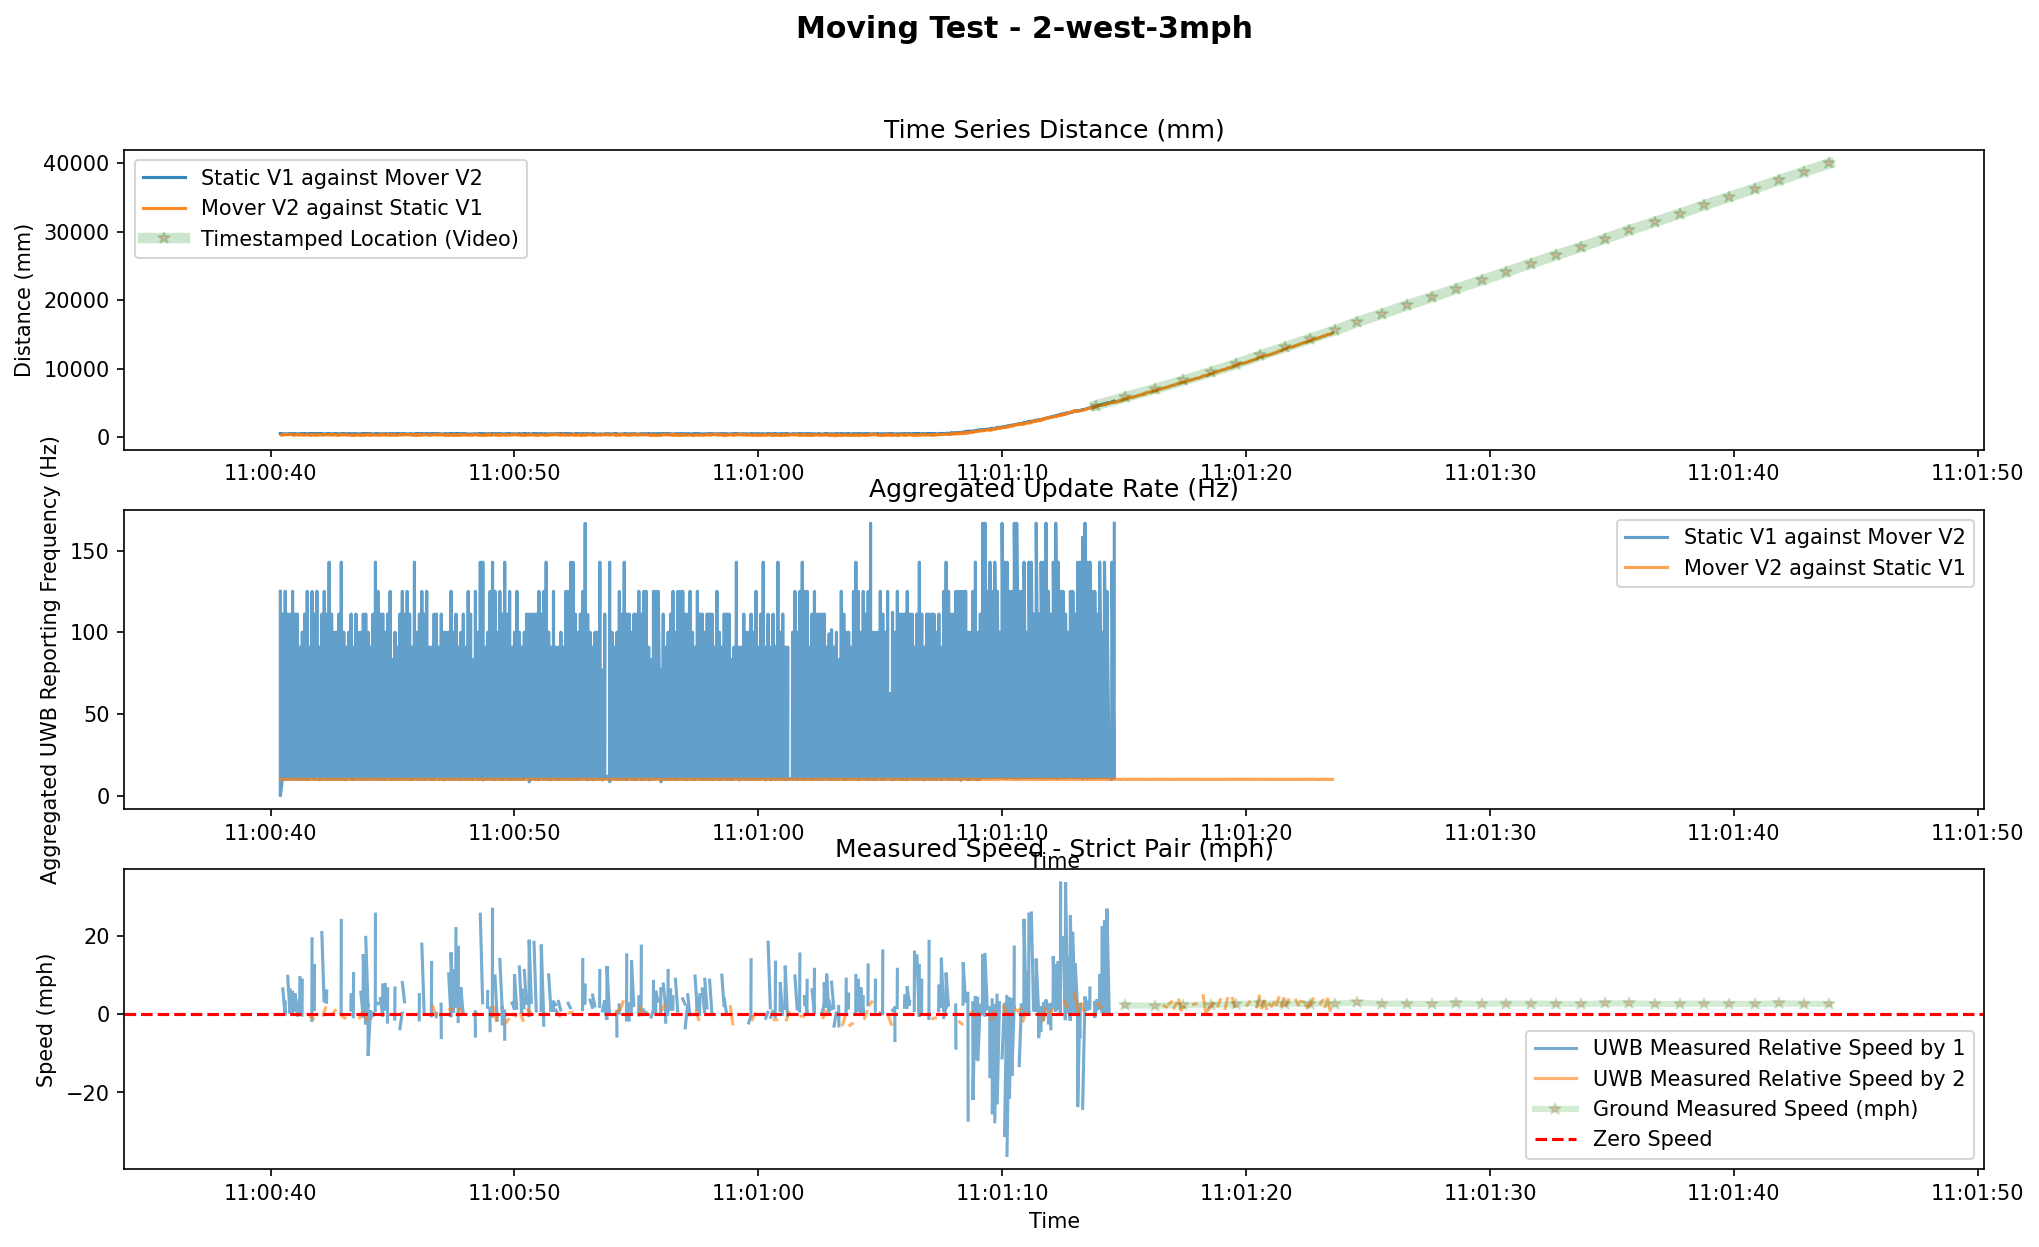

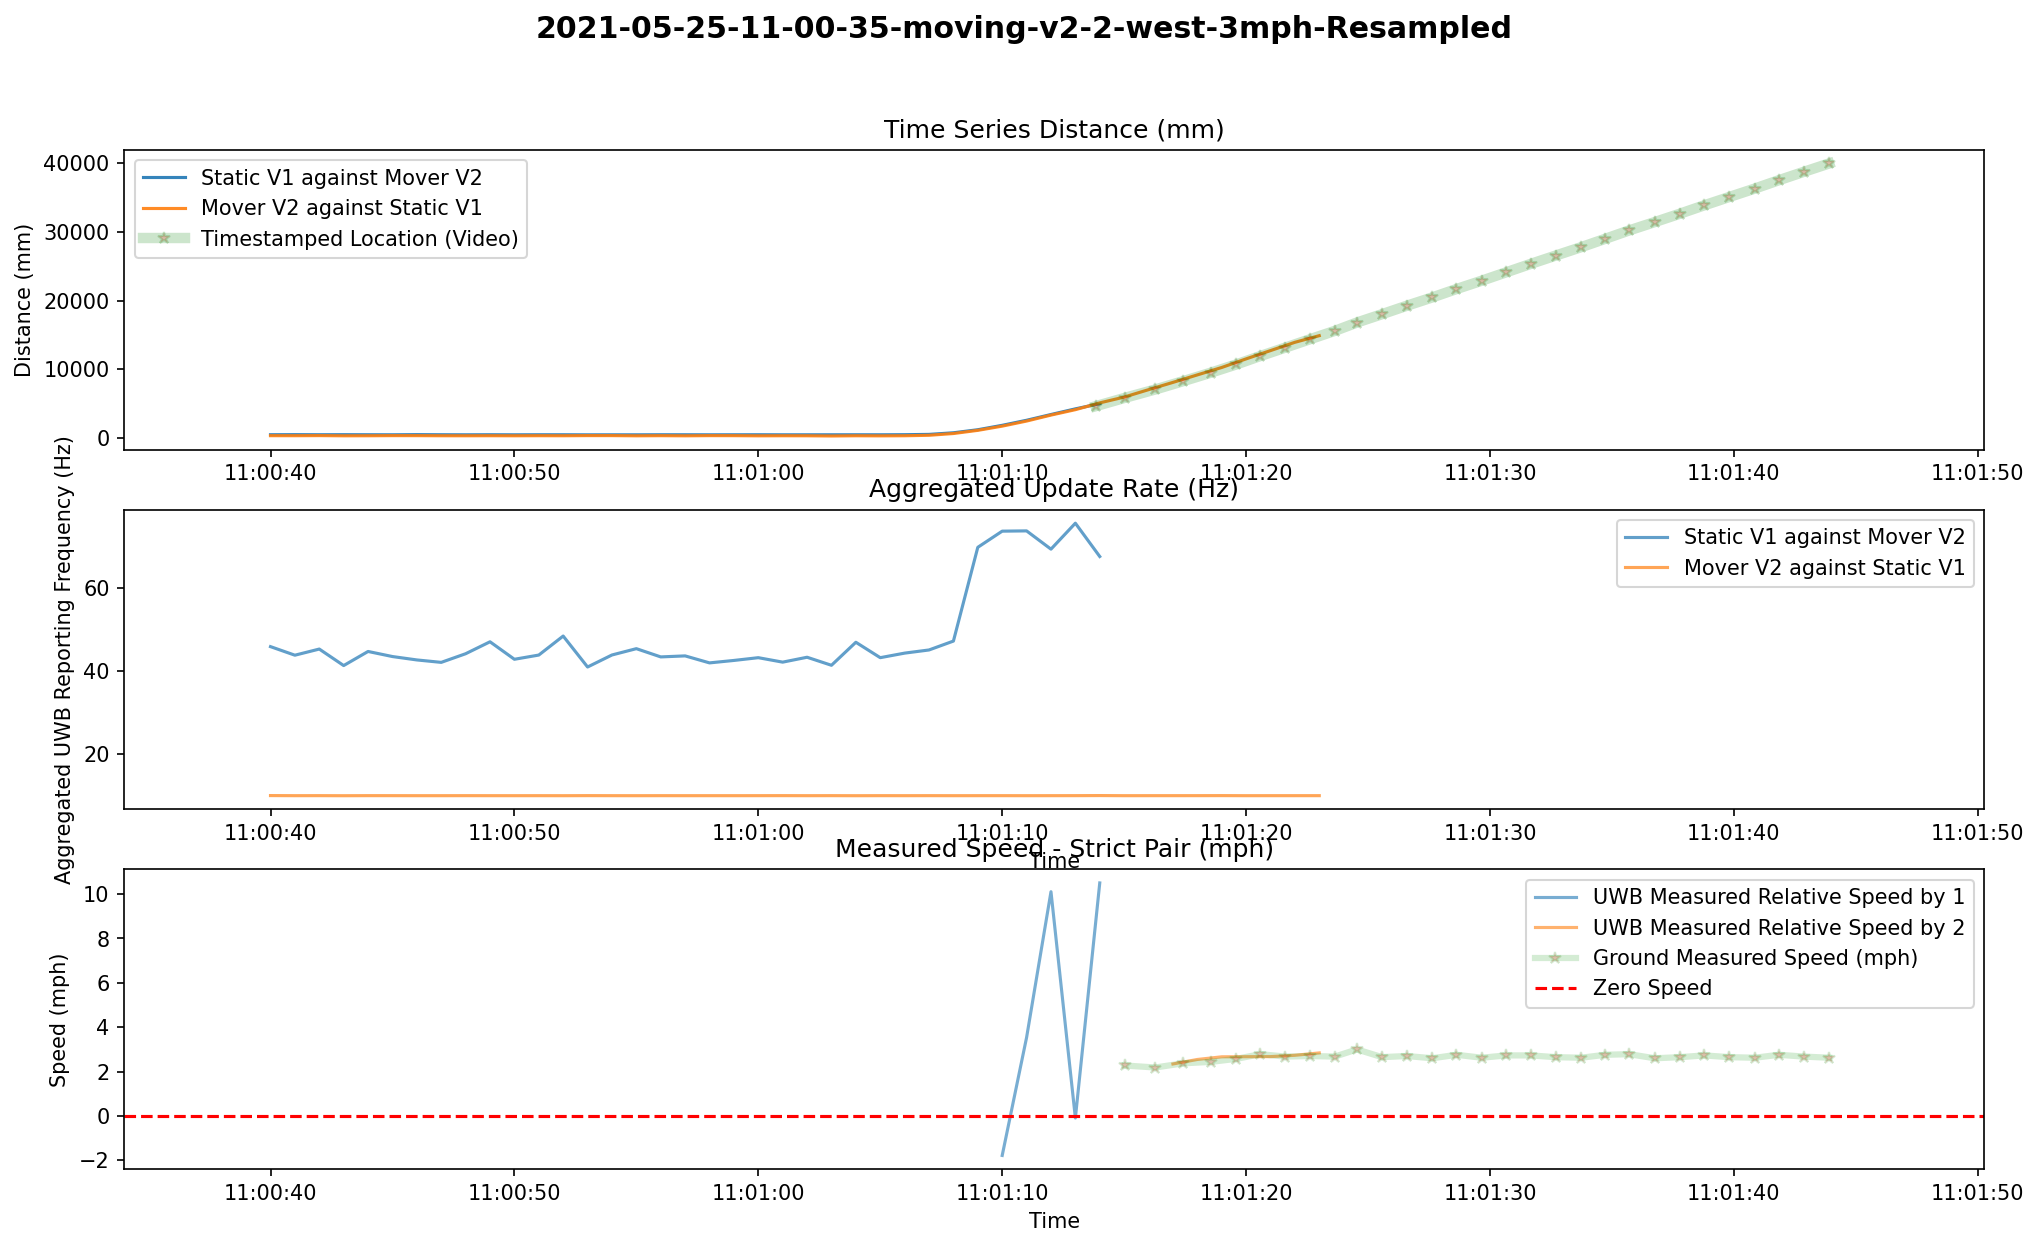

In [19]:
test_file_list, ground_truth_list = post_process_get_moving_test_data_and_timestamp(ROOT_DIR, "Moving Test 1 (V2V)", "V2", CALIBRATED_CAM_TO_V2B)
assert(len(test_file_list) == len(ground_truth_list))
for i in range(len(test_file_list)):
    test_file, ground_truth = test_file_list[i], ground_truth_list[i]
    if "2021-05-25-11-00-35-moving-v2-2-west-3mph" in test_file:
        if "data-A-user-processed_log" in test_file and os.path.basename(test_file).startswith("2021"):
            continue
        _test_csv_base = "PostProcessed_" + os.path.splitext(os.path.basename(test_file))[0] + ".csv"
        _integ_csv_base = "Integrated_ABAB_COMBO-" + _test_csv_base.split("PostProcessed_")[1].split("-data-")[0] + ".csv"
        _integ_csv_dir = os.path.join(os.path.dirname(test_file), _integ_csv_base)
        df = pd.read_csv(_integ_csv_dir)
        plot_time_series_ranging(_integ_csv_dir, ground_truth, static_veh=1, is_static_plot=False, moving_veh=2, resample_rule=RESAMPLE_RULE)
    

In [20]:
update_rate_aggregate_reporting_pairs(  df_static_veh_all_pairs, 
                                        static_master_slave_mapping.keys(), 
                                        static_focusing_slaves)

,Initiating Master,Master Side,Reporting Master X (mm),Reporting Master Y (mm),Reporting Master Z (mm),Initiating Vehicle,Initiating Vehicle Length (mm),Reporting Slave,Slave Side,Reporting Slave X (mm),...,Reporting Slave Z (mm),Reporting Vehicle,Reporting Vehicle Length (mm),Correction Distance (mm),UWB Distance (mm),Surveyed Distance (mm),Timestamp Norm (s),Timestamp Local (s),Instant Update Rate (Hz),Aggregated Update Rate (Hz)
Datetime Normalized,,,,,,,,,,,,,,,,,,,,,
2021-05-25 09:39:34.289406976,0C1A,A,290,-1190,2820,1,15470,1912,B,2420,...,1870,2,12140,29849,32574,29876.80000,1621935574.28941,1621935575.44574,NaN,NaN
2021-05-25 09:39:38.115526912,0C1A,A,290,-1190,2820,1,15470,1912,B,2420,...,1870,2,12140,29807,32532,29876.80000,1621935578.11553,1621935579.27186,0.26136,0.26136
2021-05-25 09:39:38.523275008,0C1A,A,290,-1190,2820,1,15470,1912,B,2420,...,1870,2,12140,29825,32550,29876.80000,1621935578.52327,1621935579.67961,2.45250,2.45250
2021-05-25 09:39:39.098917120,0C1A,A,290,-1190,2820,1,15470,1912,B,2420,...,1870,2,12140,29839,32564,29876.80000,1621935579.09892,1621935580.25525,1.73719,1.73719
2021-05-25 09:39:48.111336960,0C1A,A,290,-1190,2820,1,15470,1912,B,2420,...,1870,2,12140,29821,32546,29876.80000,1621935588.11134,1621935589.26767,0.11096,0.11096
2021-05-25 09:39:50.587223040,0C1A,A,290,-1190,2820,1,15470,1912,B,2420,...,1870,2,12140,29821,32546,29876.80000,1621935590.58722,1621935591.74356,0.40390,0.40390
2021-05-25 09:39:54.921603840,0C1A,A,290,-1190,2820,1,15470,1912,B,2420,...,1870,2,12140,29877,32602,29876.80000,1621935594.92160,1621935596.07794,0.23071,0.23071
2021-05-25 09:39:58.083642112,0C1A,A,290,-1190,2820,1,15470,1912,B,2420,...,1870,2,12140,29811,32536,29876.80000,1621935598.08364,1621935599.23998,0.31625,0.31625
2021-05-25 09:40:00.415326208,0C1A,A,290,-1190,2820,1,15470,1912,B,2420,...,1870,2,12140,29839,32564,29876.80000,1621935600.41533,1621935601.57166,0.42887,0.42887


In [23]:
df["Instant Update Rate (Hz)"]

0      10.10744
1       9.90697
2      10.00640
3       9.90709
4      10.00609
         ...   
2129   10.08908
2130    4.98601
2131    2.48568
2132    9.98791
2133    4.98383
Name: Instant Update Rate (Hz), Length: 2134, dtype: float64